In [1]:
#importing libraries fro the modelling 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.multiclass import OneVsOneClassifier
import warnings
warnings.filterwarnings('ignore')

In [6]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
data = pd.read_csv(file_path)
data.sample(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
1460,Male,23.000000,1.742500,105.028665,yes,yes,2.393837,3.00000,Sometimes,no,2.014990,no,0.978815,0.413220,Sometimes,Public_Transportation,Obesity_Type_I
953,Female,16.240576,1.616533,65.062945,yes,yes,2.388168,1.00000,Sometimes,no,1.438018,yes,0.110887,1.165817,no,Public_Transportation,Overweight_Level_I
1532,Male,22.705772,1.841989,122.024954,yes,yes,3.000000,2.52751,Sometimes,no,1.645338,no,1.025438,0.000000,Sometimes,Public_Transportation,Obesity_Type_II
646,Female,22.033129,1.704223,51.437985,yes,yes,2.984425,3.00000,Frequently,no,2.044694,no,2.008256,1.250871,no,Public_Transportation,Insufficient_Weight
1211,Male,30.551762,1.784377,102.872505,yes,yes,2.271306,3.00000,Sometimes,no,1.771198,no,2.000000,0.413752,Sometimes,Automobile,Obesity_Type_I


In [7]:
#Looking for statistical view of the dataset
data.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [8]:
#Getting to know the information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [9]:
#To know if the is a missing value in the dataset
data.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

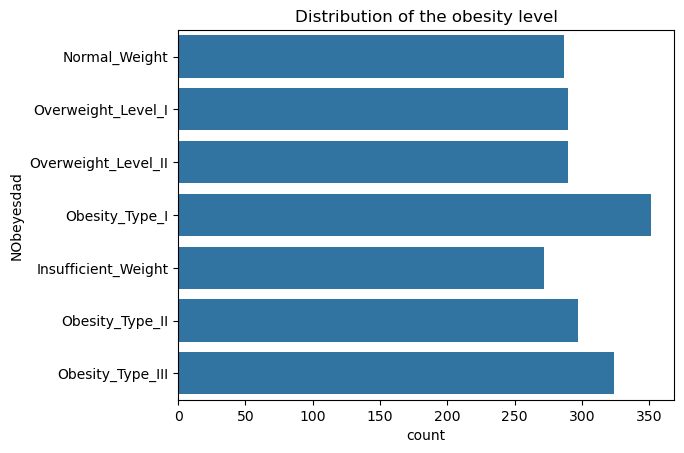

In [10]:
#Distribution of the target variable 
sns.countplot(y='NObeyesdad', data=data)
plt.title("Distribution of the obesity level")
plt.show()

In [11]:
#Preprocessing Stage 
"""
this stage we will perfrom normalization and also select and encode the objects as well
"""

'\nthis stage we will perfrom normalization and also select and encode the objects as well\n'

In [12]:
#Standardizing the contimuous numerical variabel features
continuous_features = data.select_dtypes(include = ['float']).columns.tolist()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(data[continuous_features])

In [13]:
#converting it into dataframe
scaled_df = pd.DataFrame(scaled_features, columns = scaler.get_feature_names_out(continuous_features))

In [14]:
scaled_df.head(20)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625
5,0.738817,-0.875589,-1.282647,-0.785019,0.404153,-0.013073,-1.188039,-1.080625
6,-0.206889,-2.162001,-1.206267,1.088342,0.404153,-0.013073,-0.012109,-1.080625
7,-0.364507,-0.661187,-1.282647,-0.785019,0.404153,-0.013073,2.339750,-1.080625
8,-0.049271,0.839627,-0.862558,1.088342,0.404153,-0.013073,-0.012109,0.561997
9,-0.364507,0.196421,-0.709799,-0.785019,0.404153,-0.013073,-0.012109,0.561997


In [15]:
#Combining it into the old DataFrame 
scaled_data = pd.concat([data.drop(columns = continuous_features),scaled_df],axis = 1)

In [16]:
scaled_data.head()

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,Female,yes,no,Sometimes,no,no,no,Public_Transportation,Normal_Weight,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997
1,Female,yes,no,Sometimes,yes,yes,Sometimes,Public_Transportation,Normal_Weight,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625
2,Male,yes,no,Sometimes,no,no,Frequently,Public_Transportation,Normal_Weight,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997
3,Male,no,no,Sometimes,no,no,Frequently,Walking,Overweight_Level_I,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625
4,Male,no,no,Sometimes,no,no,Sometimes,Public_Transportation,Overweight_Level_II,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625


In [17]:
#Encoding the object to convert into binary or categorical form for the model

In [18]:
categorical_columns = scaled_data.select_dtypes(include = ['object']).columns.tolist()
categorical_columns.remove('NObeyesdad')
encoder = OneHotEncoder(sparse_output = False, drop = 'first')
encoded_features = encoder.fit_transform(scaled_data[categorical_columns])

In [19]:
encoded_features

array([[0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [1., 1., 0., ..., 0., 1., 0.],
       ...,
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.]], shape=(2111, 15))

In [20]:
encoded_df = pd.DataFrame(
    encoded_features,
    columns=encoder.get_feature_names_out(categorical_columns)
)

In [21]:
encoded_df.sample(20)

,Gender_Male,family_history_with_overweight_yes,FAVC_yes,CAEC_Frequently,CAEC_Sometimes,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
311,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
230,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
628,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1960,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1853,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
830,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
268,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1837,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
907,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [22]:
#combining them together
prepped_data = pd.concat([scaled_data.drop(columns = categorical_columns),encoded_df], axis = 1)

In [23]:
prepped_data.head()

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Normal_Weight,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,Normal_Weight,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Normal_Weight,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Overweight_Level_I,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Overweight_Level_II,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [24]:
#Converting the Target into categorical form
prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes
prepped_data.head()

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [25]:
prepped_data.corr()

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
NObeyesdad,1.000000,0.236170,0.038986,0.387643,0.018522,-0.092616,0.108868,-0.129564,-0.069448,0.024908,...,0.066715,-0.023256,-0.050679,0.047318,0.114104,-0.134716,-0.017351,-0.034293,-0.003748,-0.073823
Age,0.236170,1.000000,-0.025958,0.202560,0.016291,-0.043944,-0.045304,-0.144938,-0.296931,0.048394,...,-0.061795,0.091987,-0.116283,0.082566,-0.012483,-0.018803,0.003652,0.020286,-0.554448,-0.063064
Height,0.038986,-0.025958,1.000000,0.463136,-0.038121,0.243672,0.213376,0.294709,0.051912,0.618466,...,-0.095625,0.055499,-0.133753,0.045518,0.107070,-0.127828,0.028996,-0.010471,-0.089684,0.036951
Weight,0.387643,0.202560,0.463136,1.000000,0.216125,0.107469,0.200575,-0.051436,-0.071561,0.161668,...,-0.106260,0.025746,-0.201906,-0.041778,0.259599,-0.249828,-0.021745,-0.037300,0.059332,-0.100805
FCVC,0.018522,0.016291,-0.038121,0.216125,1.000000,0.042216,0.068461,0.019939,-0.101135,-0.274505,...,-0.103902,0.014320,0.071852,-0.018655,0.082804,-0.077072,-0.029843,-0.007512,0.057966,0.013991
NCP,-0.092616,-0.043944,0.243672,0.107469,0.042216,1.000000,0.057088,0.129504,0.036326,0.067600,...,-0.146328,0.007811,-0.015624,-0.019126,0.099280,-0.092407,0.023312,0.003875,-0.056849,0.006502
CH2O,0.108868,-0.045304,0.213376,0.200575,0.068461,0.057088,1.000000,0.167236,0.011965,0.107930,...,0.159008,-0.031995,0.008036,0.049442,0.062251,-0.083272,0.026139,-0.000946,0.037504,0.008307
FAF,-0.129564,-0.144938,0.294709,-0.051436,0.019939,0.129504,0.167236,1.000000,0.058562,0.189607,...,0.024298,0.011216,0.074221,0.054739,-0.136138,0.118678,0.067129,-0.016351,-0.048751,0.108927
TUE,-0.069448,-0.296931,0.051912,-0.071561,-0.101135,0.036326,0.011965,0.058562,1.000000,0.017269,...,-0.110870,0.017613,-0.010928,0.060964,-0.102871,0.079755,-0.021725,-0.067402,0.143597,0.073404
Gender_Male,0.024908,0.048394,0.618466,0.161668,-0.274505,0.067600,0.107930,0.189607,0.017269,1.000000,...,0.062930,0.044698,-0.102633,0.034848,-0.037694,0.024163,0.057001,0.045203,-0.160184,0.039317


In [26]:
#Selecting the data and putting them into X as input feature ans the y as the target variable 
X = prepped_data.drop('NObeyesdad',axis = 1)
y = prepped_data['NObeyesdad']

In [27]:
#Splitting the Dataset into training and testing set
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42, stratify =y)

In [28]:
#Now building the OvA modelling 
model_ova = LogisticRegression(multi_class = 'ovr', max_iter =100)
model_ova.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'ovr'


In [29]:
#Making prediction on the model using the testing set 
y_pred_ova = model_ova.predict(X_test)

In [30]:
#Evaluation the model to check the model accuracy using Accuracy_score
print("One Vs All (OvA) strategy")
print(f"Accuracy of the model is {np.round(100*accuracy_score(y_test,y_pred_ova),2)}%")

One Vs All (OvA) strategy
Accuracy of the model is 76.12%


In [31]:
#Fitting in the One Vs One Model to compare the accuracy of the both model
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter = 100))
model_ovo.fit(X_train, y_train)
y_pred_ovo = model_ovo.predict(X_test)

In [32]:
print(f"The model of the OneVsOneClassifier(OvO) strategy")
print(f"The accuracy of the model is {np.round(100*accuracy_score(y_test,y_pred_ovo),2)}%")

The model of the OneVsOneClassifier(OvO) strategy
The accuracy of the model is 92.2%


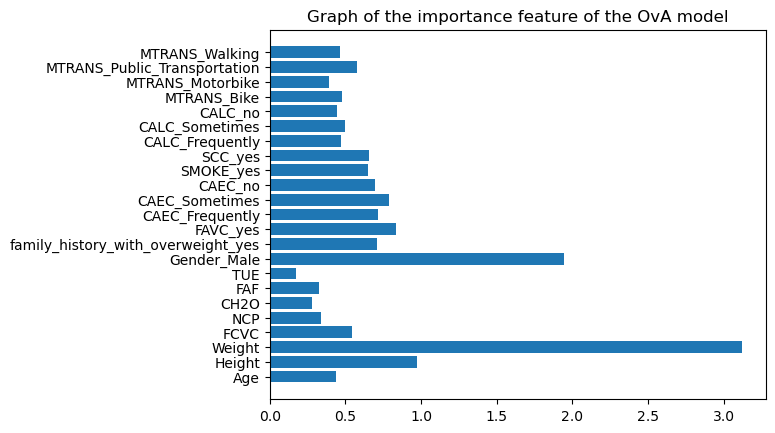

In [33]:
#Plotting the barh chat of theimportance features to see which feature affect the model most 
feature_importance = np.mean(np.abs(model_ova.coef_),axis = 0)
plt.barh(X.columns,feature_importance)
plt.title("Graph of the importance feature of the OvA model")
plt.show()

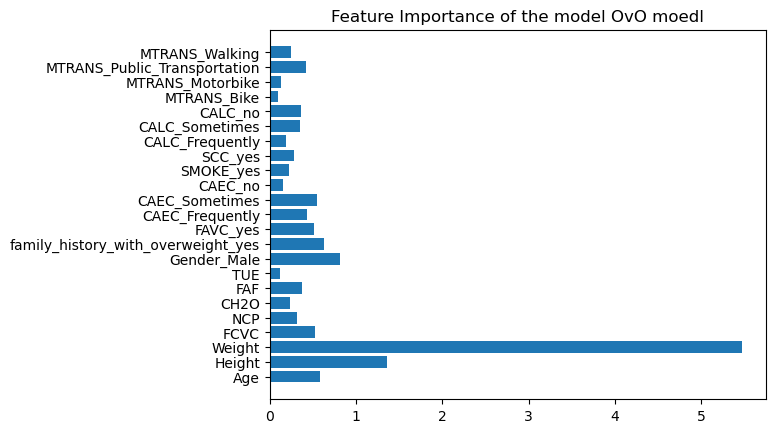

In [34]:
#Doing the same thing to the OvO model just that there will be needs of the estimators_ method
coefs = np.array([est.coef_[0] for est in model_ovo.estimators_])
feature_importance_ovo = np.mean(np.abs(coefs), axis=0)
plt.barh(X.columns, feature_importance_ovo)
plt.title("Feature Importance of the model OvO moedl")
plt.show()